# Week 3 — Model Building

**Project:** AI-Powered Fake News Detection Using Text Classification  
**Phase:** 3 of 4 (Days 15–21)  
**Notebook:** week3_model_building.ipynb

This notebook covers:
- Loading the TF-IDF feature matrices and labels (`X_train_tfidf.joblib`, `y_train.joblib`)
- Initializing the four classifier architectures with baseline hyperparameters:
  - **K-Nearest Neighbors** (KNN, non-parametric)
  - **Logistic Regression** (parametric)
  - **Random Forest** (ensemble)
  - **Multi-Layer Perceptron** (MLP, simple neural network)
- Training all four classifiers on the TF-IDF representation
- Measuring and comparing training times (in seconds)
- Serializing the fitted models to disk (`results/<name>.joblib`)
- Exporting training logs for the Phase 3 report

In [1]:
import sys
import os
from pathlib import Path

# Ensure project root is on path
PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

Working directory: /Users/anandkrishnagrnair/Documents/antigravity/keen-goodall/fake-news-detection


In [2]:
import joblib
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import ensure_dirs
from src.models import get_models, train_all, save_models

ensure_dirs("data/processed", "results/figures", "results/metrics")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Load Training Data

We load the stratified TF-IDF training split and the corresponding labels from `data/processed/`.

In [3]:
X_train_path = Path("data/processed/X_train_tfidf.joblib")
y_train_path = Path("data/processed/y_train.joblib")

if not X_train_path.exists() or not y_train_path.exists():
    raise FileNotFoundError(
        "TF-IDF training set or labels not found. Run week2_feature_engineering.ipynb first."
    )

X_train = joblib.load(X_train_path)
y_train = joblib.load(y_train_path)

print(f"Loaded TF-IDF training matrix of shape: {X_train.shape}")
print(f"Loaded labels array of shape:           {y_train.shape}")

Loaded TF-IDF training matrix of shape: (31278, 5000)
Loaded labels array of shape:           (31278,)


## 2. Model Training

We load the models with their fixed baseline hyperparameters:
- **KNN**: $K=5$, uniform weights.
- **Logistic Regression**: maximum iterations set to 1000 to prevent early stopping convergence warnings.
- **Random Forest**: 100 decision tree estimators.
- **MLP Classifier**: single hidden layer of 100 neurons, Adam solver, maximum 300 epochs.

Training times are recorded using high-precision performance counters.

In [4]:
models = get_models()
print("Initialised models:")
for name, model in models.items():
    print(f"  {name}: {model}")

Initialised models:
  KNN: KNeighborsClassifier()
  LogReg: LogisticRegression(max_iter=1000, random_state=42)
  RandomForest: RandomForestClassifier(random_state=42)
  NeuralNet: MLPClassifier(max_iter=300, random_state=42)


In [5]:
print("Starting training for all four models...")
fitted_models = train_all(models, X_train, y_train)
print("Training process complete.")

Starting training for all four models...
Training KNN... done (0.0s)
Training LogReg... done (0.1s)
Training RandomForest... done (13.3s)
Training NeuralNet... done (30.3s)
Training process complete.


## 3. Training Time Comparison

We plot and analyze the time taken to train each classifier on the 31,278 document training set.

=== Training Time Summary ===
       Model  Training Time (s)
         KNN           0.026517
      LogReg           0.108838
RandomForest          13.313324
   NeuralNet          30.252218


/var/folders/yv/w6571qrn2m74xpc6m96ljlzm0000gn/T/ipykernel_29930/294602422.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=times_df, x="Model", y="Training Time (s)", ax=ax, palette="viridis")


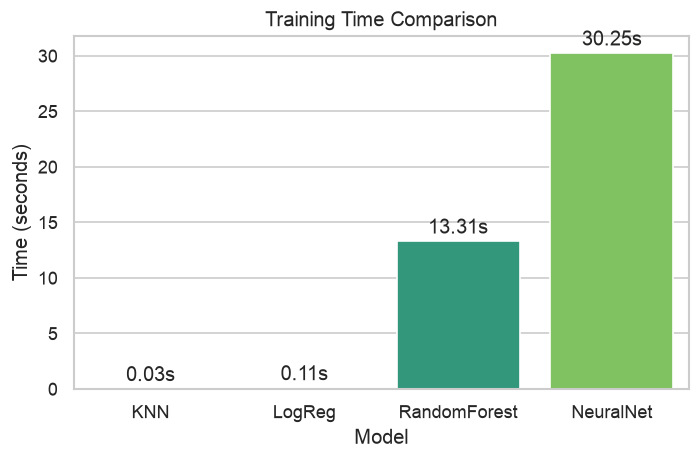

Saved: results/figures/training_times.png


In [6]:
times_dict = {name: info[1] for name, info in fitted_models.items()}
times_df = pd.DataFrame(list(times_dict.items()), columns=["Model", "Training Time (s)"])
print("=== Training Time Summary ===")
print(times_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=times_df, x="Model", y="Training Time (s)", ax=ax, palette="viridis")
ax.set_title("Training Time Comparison")
ax.set_ylabel("Time (seconds)")
for i, v in enumerate(times_df["Training Time (s)"]):
    ax.text(i, v + (max(times_df["Training Time (s)"]) * 0.01), f"{v:.2f}s", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("results/figures/training_times.png", dpi=150)
plt.show()
print("Saved: results/figures/training_times.png")

## 4. Model Serialization

We serialize the fitted model weights so they can be loaded by the evaluation module in Phase 4.

In [7]:
save_models(fitted_models)
print("Saved all fitted model files (.joblib) to results/")

Saved: results/KNN.joblib
Saved: results/LogReg.joblib
Saved: results/RandomForest.joblib
Saved: results/NeuralNet.joblib
Saved all fitted model files (.joblib) to results/


## 5. Exporting Training Metrics

We save the precise training times to the metrics folder for use in the Phase 3 report.

In [8]:
joblib.dump(times_dict, "results/metrics/phase3_training_times.joblib")
print("Saved training times dictionary to results/metrics/phase3_training_times.joblib")

Saved training times dictionary to results/metrics/phase3_training_times.joblib


## 6. Hyperparameter Tuning

We perform a Grid Search Cross-Validation (3-fold) on Logistic Regression and Random Forest to find the best hyperparameters and compare them with the baseline defaults.

In [ ]:
from src.models import tune_hyperparameters
tuned_info = tune_hyperparameters(X_train, y_train)
joblib.dump(tuned_info["LogReg"], "results/LogReg_tuned.joblib")
joblib.dump(tuned_info["RandomForest"], "results/RandomForest_tuned.joblib")
joblib.dump(tuned_info["LogReg_params"], "results/metrics/logreg_best_params.joblib")
joblib.dump(tuned_info["RandomForest_params"], "results/metrics/randomforest_best_params.joblib")
print("Tuning complete and tuned models saved.")